In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import cv2


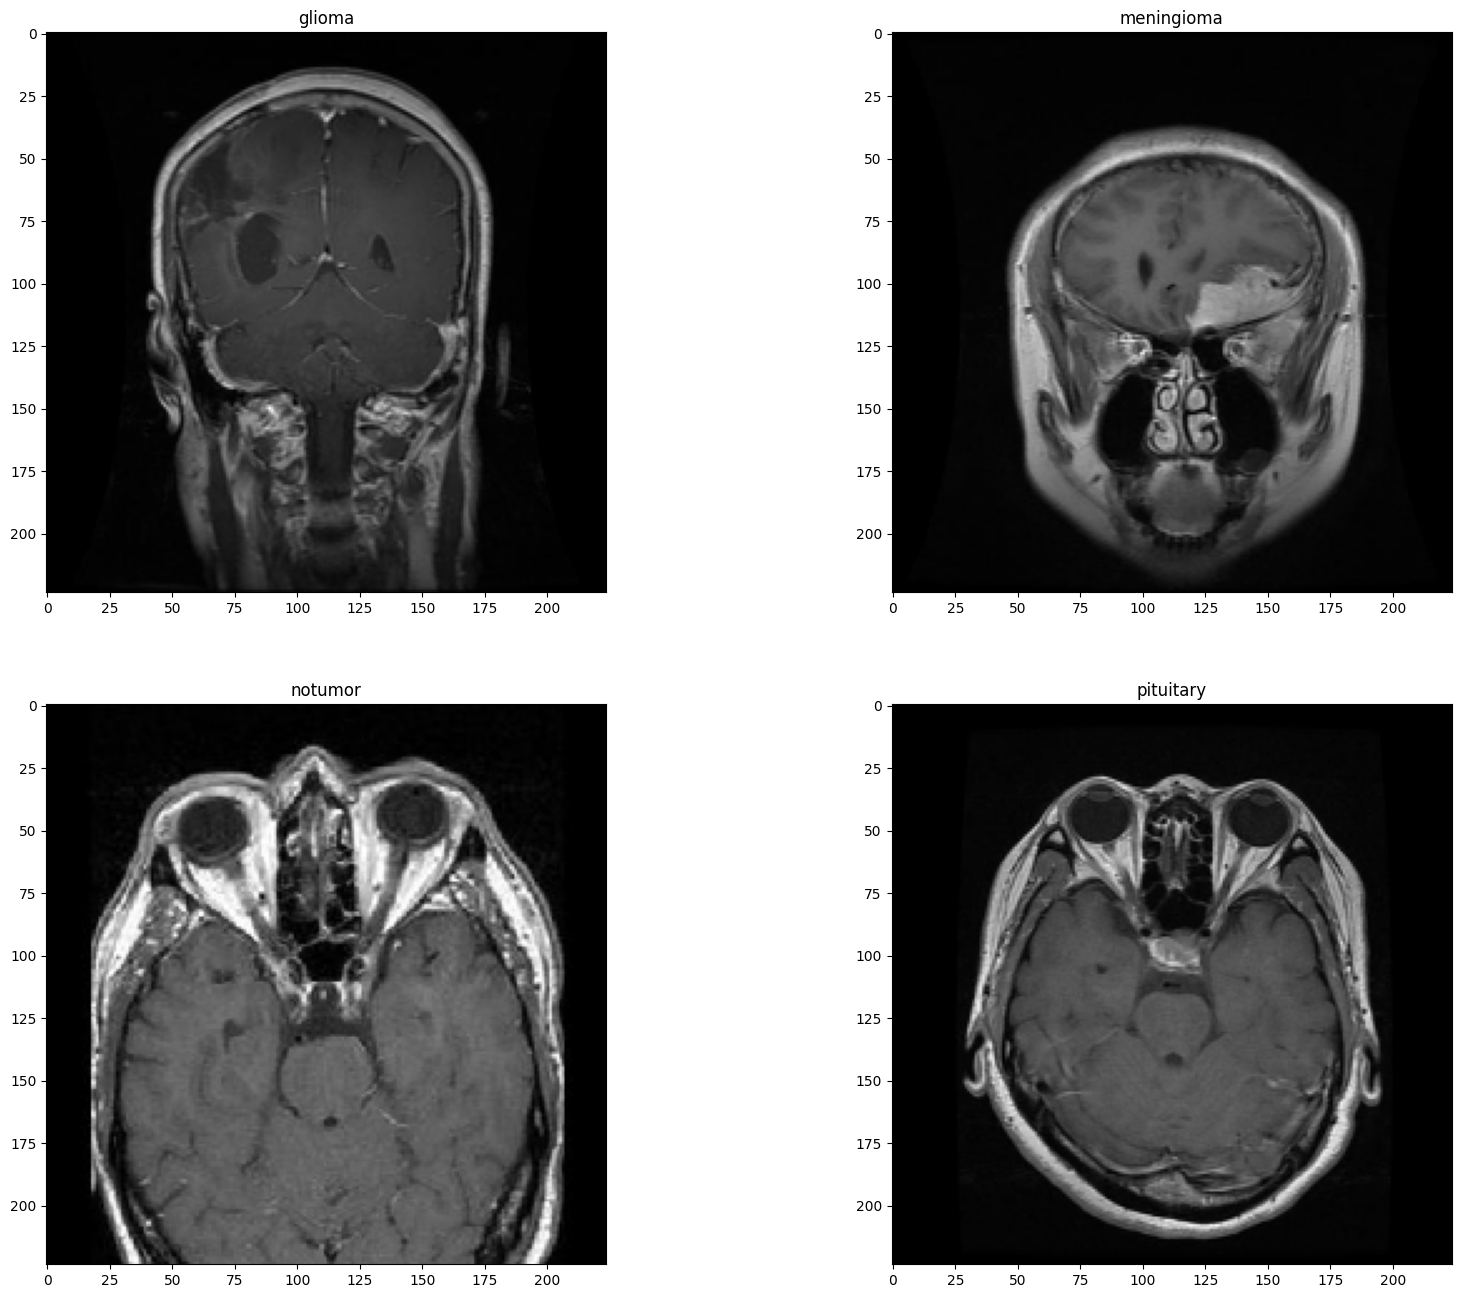

In [ ]:
data_dir = ('/content/drive/MyDrive/dataset_RE/Training')
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
plt.figure(figsize=(20, 16))

images_path = ['/glioma/Tr-gl_0010.jpg', '/meningioma/Tr-meTr_0000.jpg', '/notumor/Tr-noTr_0000.jpg', '/pituitary/Tr-piTr_0000.jpg']


for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    img = cv2.imread(data_dir + images_path[i])
    img = cv2.resize(img, (224, 224))
    plt.imshow(img)
    plt.title(categories[i])


In [ ]:
import cv2
import os
import imutils
from tqdm import tqdm

# Menentukan path dataset
base_dir = '/content/drive/My Drive/dataset_RE'
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']  # Daftar label untuk gambar
image_size = 200  # Ukuran gambar yang diubah

# Membuat folder 'cropped' jika belum ada
cropped_dir = os.path.join(base_dir, 'cropped')
if not os.path.exists(cropped_dir):
    os.makedirs(cropped_dir)

# Iterasi untuk folder 'Training' dan 'Testing'
for folder in ['Training', 'Testing']:
    for label in labels:
        input_folder = os.path.join(base_dir, folder, label)
        output_folder = os.path.join(cropped_dir, folder, label)

        # Membuat folder label di dalam folder 'cropped' jika belum ada
        if not os.path.exists(output_folder):
            os.makedirs(output_folder)

        # Loop untuk semua gambar di folder training atau testing
        for file in tqdm(os.listdir(input_folder)):
            input_image_path = os.path.join(input_folder, file)
            img = cv2.imread(input_image_path)

            # Mengubah ukuran gambar menjadi 224x224
            img = cv2.resize(img, dsize=(224, 224), interpolation=cv2.INTER_CUBIC)

            # Mengubah gambar menjadi grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            # Aplikasikan GaussianBlur untuk mengurangi noise
            gray = cv2.GaussianBlur(gray, (5, 5), 0)

            # Threshold gambar untuk membuat gambar biner, lalu lakukan erosi dan dilasi untuk menghilangkan noise
            thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
            thresh = cv2.erode(thresh, None, iterations=2)
            thresh = cv2.dilate(thresh, None, iterations=2)

            # Temukan kontur dalam gambar threshold
            cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cnts = imutils.grab_contours(cnts)

            # Ambil kontur terbesar
            c = max(cnts, key=cv2.contourArea)

            # Temukan titik ekstrem (left, right, top, bottom)
            extLeft = tuple(c[c[:, :, 0].argmin()][0])
            extRight = tuple(c[c[:, :, 0].argmax()][0])
            extTop = tuple(c[c[:, :, 1].argmin()][0])
            extBot = tuple(c[c[:, :, 1].argmax()][0])

            # Lakukan cropping berdasarkan titik ekstrem
            ADD_PIXELS = 0  # Tidak ada tambahan piksel untuk margin
            new_img = img[extTop[1] - ADD_PIXELS:extBot[1] + ADD_PIXELS,
                          extLeft[0] - ADD_PIXELS:extRight[0] + ADD_PIXELS].copy()

            # Menyimpan gambar yang telah di-crop ke dalam folder 'cropped'
            output_image_path = os.path.join(output_folder, file)
            cv2.imwrite(output_image_path, new_img)

    print(f"Finished processing {folder}")


100%|██████████| 1457/1457 [00:48<00:00, 29.85it/s]


Finished processing Training


100%|██████████| 300/300 [00:07<00:00, 41.28it/s]

Finished processing Testing


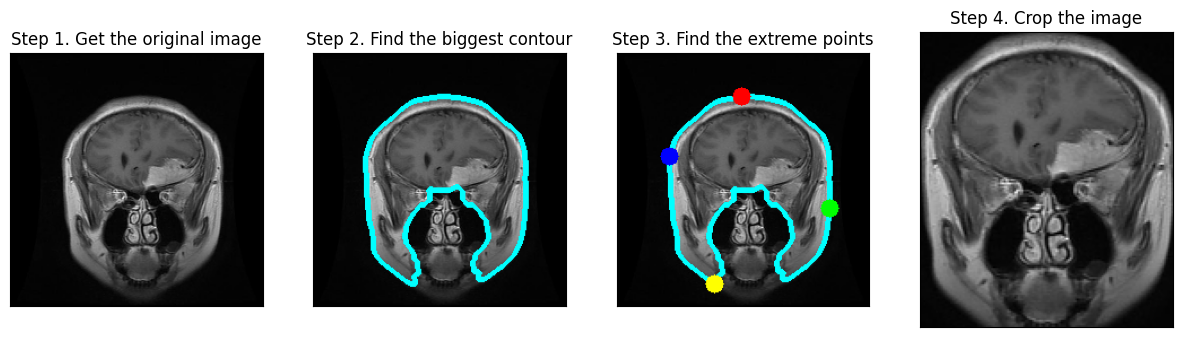

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(141)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('Step 1. Get the original image')
plt.subplot(142)
plt.imshow(img_cnt)
plt.xticks([])
plt.yticks([])
plt.title('Step 2. Find the biggest contour')
plt.subplot(143)
plt.imshow(img_pnt)
plt.xticks([])
plt.yticks([])
plt.title('Step 3. Find the extreme points')
plt.subplot(144)
plt.imshow(new_img)
plt.xticks([])
plt.yticks([])
plt.title('Step 4. Crop the image')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/dataset_RE/cropped/Training/glioma'